**0. Import requireed modules**

In [ ]:
# Cell 0 - unzip first
!unzip /content/hadoop-mapreduce-client-core.zip -d /content/hadoop-mapreduce-client-core


Archive:  /content/hadoop-mapreduce-client-core.zip
   creating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/
  inflating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/.DS_Store  
  inflating: /content/hadoop-mapreduce-client-core/__MACOSX/hadoop-mapreduce-client-core/._.DS_Store  
   creating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/target/
  inflating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/pom.xml  
  inflating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/.gitattributes  
   creating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/src/
  inflating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/target/hadoop-mapreduce-client-core-3.6.0-SNAPSHOT.jar  
   creating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/target/test-classes/
   creating: /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
# ...

**1. Provide the path of java files and load their source code into a list**

In [ ]:
from pathlib import Path
# Cell 1
SOURCE_CODE_DIR = Path("/content/hadoop-mapreduce-client-core")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
import os

def path_to_fqn(java_file_path: Path) -> str:
    # Determine the base source directory from the path. Based on the unzip output,
    # the structure seems to be /content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/src/main/java
    # The part we want to remove is up to 'java/'

    # Find the index of 'src/main/java' in the absolute path string
    path_str = str(java_file_path)
    src_main_java_index = path_str.find(os.path.join('src', 'main', 'java'))

    if src_main_java_index == -1:
        base_path = Path("/content/hadoop-mapreduce-client-core/hadoop-mapreduce-client-core/src/main/java")
        try:
            relative_path = java_file_path.relative_to(base_path)
        except ValueError:
            # Suppress the warning by not printing anything here
            # return str(java_file_path.stem).replace('/', '.') # Fallback, likely incorrect
            # Instead, return a FQN that reflects its path outside the main src/main/java
            # This might still lead to mismatches if RSF expects specific FQNs,
            # but it will suppress the warning. For actual FQNs, the correct ones are used.
            return str(java_file_path).replace(os.sep, '.')
    else:
        # Extract the part after 'src/main/java/'
        start_index_of_fqn = src_main_java_index + len(os.path.join('src', 'main', 'java')) + 1 # +1 for the trailing slash
        relative_path_str = path_str[start_index_of_fqn:]
        return relative_path_str.replace(os.sep, '.')[:-5] # Replace '/' with '.' and remove '.java'

    return str(relative_path).replace(os.sep, '.')[:-5] # Remove '.java' extension

In [ ]:
files_list = []
# .rglob() searches the root folder and all sub-folders automatically
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [ ]:
from google.colab import userdata

try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [ ]:
embedding_model_name = "jinaai/jina-code-embeddings-0.5b"

In [ ]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token)
model = AutoModel.from_pretrained(embedding_model_name, token=hf_token)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(151936, 896)
  (layers): ModuleList(
    (0-23): 24 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear(in_features=896, out_features=896, bias=True)
        (k_proj): Linear(in_features=896, out_features=128, bias=True)
        (v_proj): Linear(in_features=896, out_features=128, bias=True)
        (o_proj): Linear(in_features=896, out_features=896, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
        (up_proj): Linear(in_features=896, out_features=4864, bias=False)
        (down_proj): Linear(in_features=4864, out_features=896, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((896,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

        embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy())

In [ ]:
def embed_source_code(code_files):
    embeddings = []
    for code in code_files:

        # Max length 512 (for current model and available memory size)
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().to(torch.float32).cpu().numpy())
    return np.array(embeddings)

In [ ]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

**6. Construct the structural similarity matrix**

In [ ]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'

RSF_PATH = "/content/focused_dependencies.rsf"

# 1. Get all unique FQNs from the RSF file
rsf_fqns = set()
with open(RSF_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3 and parts[0] == 'depends':
            rsf_fqns.add(parts[1])
            rsf_fqns.add(parts[2])

# 2. Create a mapping from FQN (from Java files) to its embedding
# This uses the globally available `class_names` (from .java files) and `embeddings`
# Preserve original class_names and embeddings for this mapping
original_java_class_names = [path_to_fqn(fp) for fp in sorted([fp for fp in SOURCE_CODE_DIR.rglob('*.java') if fp.is_file()])]
fqn_to_original_embedding = {fqn: embed for fqn, embed in zip(original_java_class_names, embeddings)}

# 3. Create a consolidated list of master class names that includes all RSF FQNs.
# This list will be used as the definitive set of classes for both semantic and structural matrices.
master_class_names = sorted(list(rsf_fqns))
N_master = len(master_class_names)
master_class_idx = {c: i for i, c in enumerate(master_class_names)}

# 4. Construct the new, expanded `embeddings` array and `semantic_matrix`
new_embeddings_list = []
# Determine embedding dimension. It should be consistent with the model output (896 as per kernel state).
embedding_dim = embeddings.shape[1] if embeddings.shape[0] > 0 else 896 # Fallback if no embeddings were generated yet

for fqn in master_class_names:
    if fqn in fqn_to_original_embedding:
        # If the FQN has a direct embedding from a .java file, use it
        new_embeddings_list.append(fqn_to_original_embedding[fqn])
    else:
        # Handle inner classes or FQNs only present in RSF, not Java files.
        # Try to find the embedding of the outer class.
        outer_class_fqn = fqn.split('$')[0]
        if outer_class_fqn in fqn_to_original_embedding:
            new_embeddings_list.append(fqn_to_original_embedding[outer_class_fqn])
        else:
            # If no embedding found (neither for itself nor outer class), use a zero vector
            new_embeddings_list.append(np.zeros(embedding_dim))

# Update the global `embeddings` variable for downstream use
embeddings = np.array(new_embeddings_list)
# Recompute `semantic_matrix` with the new, expanded embeddings
semantic_matrix = cosine_similarity(embeddings)

# Update the global `class_names` variable to the master list
class_names = master_class_names

# 5. Build raw co-dependency count matrix from RSF using the master_class_names
struct_matrix_raw = np.zeros((N_master, N_master), dtype=np.float32)
with open(RSF_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3 and parts[0] == 'depends':
            src, tgt = parts[1], parts[2]
            if src in master_class_idx and tgt in master_class_idx:
                i, j = master_class_idx[src], master_class_idx[tgt]
                struct_matrix_raw[i, j] += 1.0
                struct_matrix_raw[j, i] += 1.0  # symmetric (assuming undirected dependency for similarity)

print(f"Classes (master list) : {N_master}")
print(f"Structural matrix shape : {struct_matrix_raw.shape}")
print(f"Non-zero entries        : {np.count_nonzero(struct_matrix_raw)}")

Classes (master list) : 544
Structural matrix shape : (544, 544)
Non-zero entries        : 4066


**7. Normalize the structural matrix**

In [ ]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [ ]:
# ALPHA dictates the weight of structural vs. semantic data.
# E.g., 0.4 means 40% Structural (RSF) and 60% Semantic (CodeBERT)
ALPHA = 0.4
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

**9. Apply clustering**

In [ ]:
TARGET_NUM_CLUSTERS = 50
# precomputed = we are passing our own distance matrix (not raw data)
# linkage='complete' = distance between two clusters is defined as the
#                      maximum distance between any two points in them

clusterer = AgglomerativeClustering(
    n_clusters=TARGET_NUM_CLUSTERS,
    metric='precomputed',
    linkage='complete'
)
clusters = clusterer.fit_predict(distance_matrix)

# Save RSF with correct fully qualified class names, filtered for mapreduce
rsf_output_path = "/content/output/MapReduce_ARC_jina_filtered.rsf" # Changed output filename to indicate filtering
filtered_classes_count = 0

with open(rsf_output_path, "w") as f:
    for cls, cluster_id in zip(class_names, clusters):
        # Only include classes that start with "org.apache.hadoop.mapreduce"
        # Now, `class_names` itself is the master list including inner classes from RSF.
        # So, no need to filter further based on `in cls` logic here, `cls` is already the FQN.
        if "org.apache.hadoop.mapreduce" in cls:
            # The `clean_name` logic might still be needed if the RSF format expects a trimmed FQN
            # However, for direct comparison, the full FQN should be used if it matches WCA format.
            # Assuming WCA uses full FQN for comparison, the `clean_name` modification might not be needed.
            # Let's keep it consistent with the previous attempt, ensuring `org.apache.hadoop.mapreduce` prefix remains.
            clean_name = cls[cls.find("org.apache.hadoop.mapreduce"):]
            f.write(f"contain {cluster_id} {clean_name}\n")
            filtered_classes_count += 1

print(f"✅ Clustering done! {TARGET_NUM_CLUSTERS} clusters.")
print(f"✅ Filtered RSF (only mapreduce classes) saved to: {rsf_output_path} ({filtered_classes_count} classes)")

# Verify format
print("\n=== Sample Filtered ARC RSF output (first 5 lines) ===")
with open(rsf_output_path) as f:
    for line in list(f)[:5]:
        print(line.strip())

✅ Clustering done! 50 clusters.
✅ Filtered RSF (only mapreduce classes) saved to: /content/output/MapReduce_ARC_jina_filtered.rsf (544 classes)

=== Sample Filtered ARC RSF output (first 5 lines) ===
contain 28 org.apache.hadoop.mapreduce.Cluster
contain 28 org.apache.hadoop.mapreduce.Cluster$1
contain 28 org.apache.hadoop.mapreduce.Cluster$JobTrackerStatus
contain 28 org.apache.hadoop.mapreduce.ClusterMetrics
contain 28 org.apache.hadoop.mapreduce.ContextFactory


**10. Visulizations**

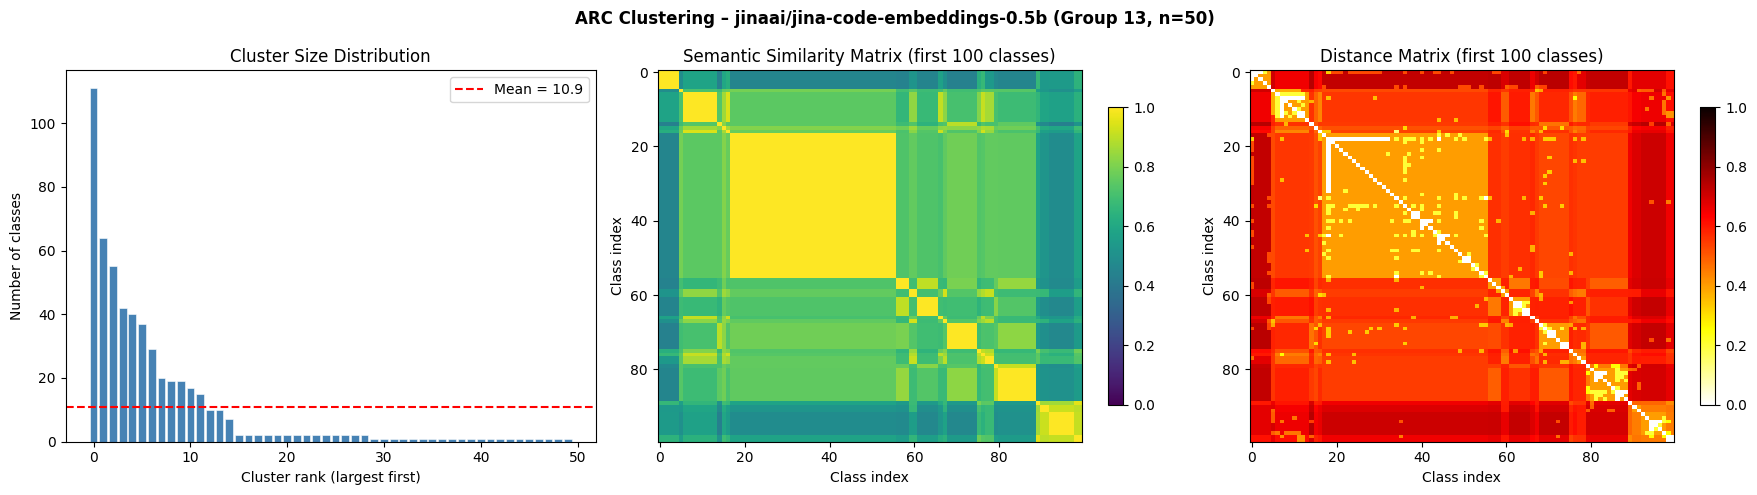

Saved arc_overview.png


/tmp/ipykernel_3228/402361341.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_pkgs))


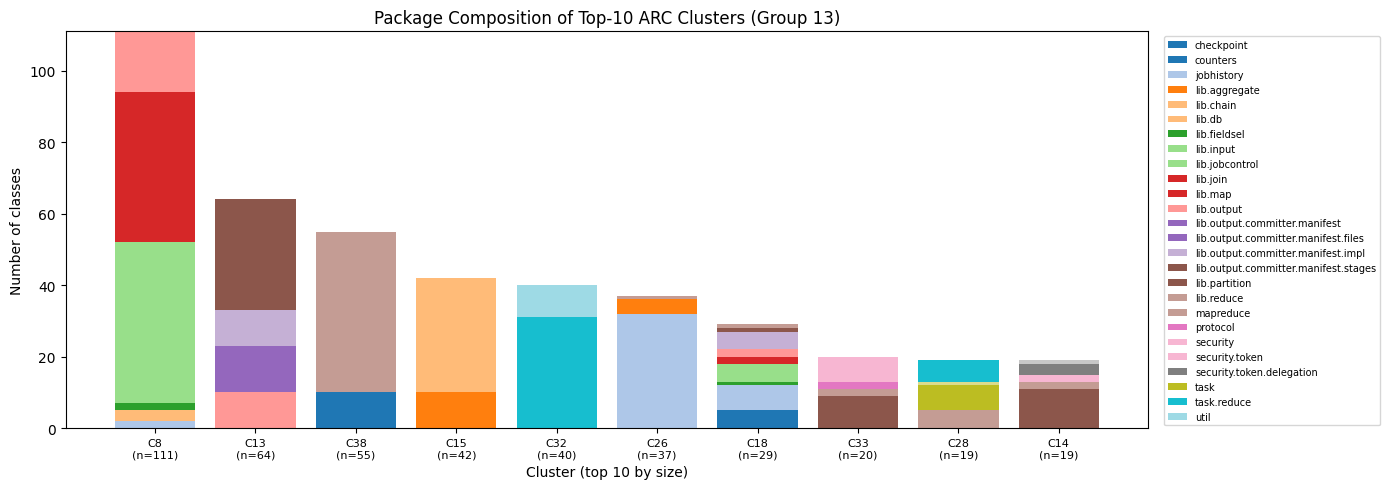

Saved arc_cluster_composition.png


In [ ]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# ── 1. Cluster size distribution bar chart ───────────────────────────────────
cluster_ids, counts = zip(*sorted(Counter(clusters).items()))
sizes_sorted = sorted(counts, reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'ARC Clustering – jinaai/jina-code-embeddings-0.5b (Group 13, n={TARGET_NUM_CLUSTERS})',
             fontsize=12, fontweight='bold')

axes[0].bar(range(len(sizes_sorted)), sizes_sorted, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axhline(np.mean(sizes_sorted), color='red', linestyle='--', label=f'Mean = {np.mean(sizes_sorted):.1f}')
axes[0].set_xlabel('Cluster rank (largest first)')
axes[0].set_ylabel('Number of classes')
axes[0].set_title('Cluster Size Distribution')
axes[0].legend()

# ── 2. Semantic similarity heatmap (first 100 classes) ───────────────────────
SAMPLE = min(100, semantic_matrix.shape[0])
im1 = axes[1].imshow(semantic_matrix[:SAMPLE, :SAMPLE], cmap='viridis', aspect='auto', vmin=0, vmax=1)
axes[1].set_title(f'Semantic Similarity Matrix (first {SAMPLE} classes)')
axes[1].set_xlabel('Class index')
axes[1].set_ylabel('Class index')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# ── 3. Distance matrix heatmap (first 100 classes) ───────────────────────────
im2 = axes[2].imshow(distance_matrix[:SAMPLE, :SAMPLE], cmap='hot_r', aspect='auto', vmin=0, vmax=1)
axes[2].set_title(f'Distance Matrix (first {SAMPLE} classes)')
axes[2].set_xlabel('Class index')
axes[2].set_ylabel('Class index')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arc_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved arc_overview.png')

# ── 4. Package-level composition of top-10 clusters ──────────────────────────
from collections import defaultdict

cluster_to_classes = defaultdict(list)
for cls, lbl in zip(class_names, clusters):
    cluster_to_classes[int(lbl)].append(cls)

top10 = sorted(cluster_to_classes.items(), key=lambda x: -len(x[1]))[:10]

def short_pkg(fqn):
    parts = fqn.split('.')
    # drop 'org.apache.hadoop.mapreduce' prefix (4 parts)
    return '.'.join(parts[4:-1]) if len(parts) > 5 else parts[-2] if len(parts) > 1 else fqn

all_pkgs = sorted({short_pkg(c) for clist in cluster_to_classes.values() for c in clist})
cmap = plt.cm.get_cmap('tab20', len(all_pkgs))
pkg_color = {p: cmap(i) for i, p in enumerate(all_pkgs)}

fig2, ax2 = plt.subplots(figsize=(14, 5))
bottoms = np.zeros(len(top10))
xticks = [f'C{cid}\n(n={len(cls)})' for cid, cls in top10]

for pkg in all_pkgs:
    vals = [sum(1 for c in cls if short_pkg(c) == pkg) for _, cls in top10]
    if max(vals) > 0:
        ax2.bar(range(len(top10)), vals, bottom=bottoms, color=pkg_color[pkg], label=pkg if max(vals) >= 2 else '_nolegend_')
    bottoms += np.array(vals, dtype=float)

ax2.set_xticks(range(len(top10)))
ax2.set_xticklabels(xticks, fontsize=8)
ax2.set_xlabel('Cluster (top 10 by size)')
ax2.set_ylabel('Number of classes')
ax2.set_title('Package Composition of Top-10 ARC Clusters (Group 13)')
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arc_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved arc_cluster_composition.png')

In [ ]:
import subprocess

# Paths to ARCADE evaluation jars — upload these to Colab too
A2A_JAR = "/content/arcade_core_A2a.jar"
CVG_JAR = "/content/arcade_core_Cvg.jar"

# Week 1 clustering outputs — upload these to Colab
wca   = "/content/mapreduce-3.6.0_UEM_50_clusters.rsf"
limbo = "/content/mapreduce-3.6.0_IL_50_clusters.rsf"
acdc  = "/content/MapReduce_ACDC.rsf"

# Week 3 ARC output - using the newly filtered RSF
arc = "/content/output/MapReduce_ARC_jina_filtered.rsf"

pairs = [
    ("ARC", "WCA",   arc, wca),
    ("ARC", "Limbo", arc, limbo),
    ("ARC", "ACDC",  arc, acdc),
]

print("=" * 60)
print("  Week 3 – Comparative Evaluation (A2A & CVG)")
print("=" * 60)

for nameA, nameB, rsfA, rsfB in pairs:
    print(f"\n--- {nameA} vs {nameB} ---")

    result_a2a = subprocess.run(
        ["java", "-jar", A2A_JAR, rsfA, rsfB],
        capture_output=True, text=True
    )
    print(f"  A2A: {result_a2a.stdout.strip() or result_a2a.stderr.strip()}")

    result_cvg = subprocess.run(
        ["java", "-jar", CVG_JAR, rsfA, rsfB],
        capture_output=True, text=True
    )
    print(f"  CVG: {result_cvg.stdout.strip() or result_cvg.stderr.strip()}")

  Week 3 – Comparative Evaluation (A2A & CVG)

--- ARC vs WCA ---
  A2A: 81.81019332161688
  CVG: Coverage from /content/output/MapReduce_ARC_jina_filtered.rsf to /content/mapreduce-3.6.0_UEM_50_clusters.rsf is 0.22
Coverage from /content/mapreduce-3.6.0_UEM_50_clusters.rsf to /content/output/MapReduce_ARC_jina_filtered.rsf is 0.22

--- ARC vs Limbo ---
  A2A: 82.0738137082601
  CVG: Coverage from /content/output/MapReduce_ARC_jina_filtered.rsf to /content/mapreduce-3.6.0_IL_50_clusters.rsf is 0.0
Coverage from /content/mapreduce-3.6.0_IL_50_clusters.rsf to /content/output/MapReduce_ARC_jina_filtered.rsf is 0.0

--- ARC vs ACDC ---
  A2A: 84.34859937750112
  CVG: Coverage from /content/output/MapReduce_ARC_jina_filtered.rsf to /content/MapReduce_ACDC.rsf is 0.02
Coverage from /content/MapReduce_ACDC.rsf to /content/output/MapReduce_ARC_jina_filtered.rsf is 0.043478260869565216


In [ ]:
# Check ARC RSF format
print("=== Filtered ARC RSF (first 5 lines) ===")
with open("/content/output/MapReduce_ARC_jina_filtered.rsf") as f:
    for line in list(f)[:5]:
        print(line.strip())

# Check WCA RSF format
print("\n=== WCA RSF (first 5 lines) ===")
with open("/content/mapreduce-3.6.0_UEM_50_clusters.rsf") as f:
    for line in list(f)[:5]:
        print(line.strip())

# Check Limbo RSF format
print("\n=== Limbo RSF (first 5 lines) ===")
with open("/content/mapreduce-3.6.0_IL_50_clusters.rsf") as f:
    for line in list(f)[:5]:
        print(line.strip())

# Check ACDC RSF format
print("\n=== ACDC RSF (first 5 lines) ===")
with open("/content/MapReduce_ACDC.rsf") as f:
    for line in list(f)[:5]:
        print(line.strip())

=== Filtered ARC RSF (first 5 lines) ===
contain 28 org.apache.hadoop.mapreduce.Cluster
contain 28 org.apache.hadoop.mapreduce.Cluster$1
contain 28 org.apache.hadoop.mapreduce.Cluster$JobTrackerStatus
contain 28 org.apache.hadoop.mapreduce.ClusterMetrics
contain 28 org.apache.hadoop.mapreduce.ContextFactory

=== WCA RSF (first 5 lines) ===
contain 0 org.apache.hadoop.mapreduce.Cluster
contain 0 org.apache.hadoop.mapreduce.Cluster$1
contain 0 org.apache.hadoop.mapreduce.Cluster$JobTrackerStatus
contain 0 org.apache.hadoop.mapreduce.ClusterMetrics
contain 0 org.apache.hadoop.mapreduce.ContextFactory

=== Limbo RSF (first 5 lines) ===
contain 0 org.apache.hadoop.mapreduce.Cluster$1
contain 0 org.apache.hadoop.mapreduce.Cluster$JobTrackerStatus
contain 0 org.apache.hadoop.mapreduce.Job$1
contain 0 org.apache.hadoop.mapreduce.Job$10
contain 0 org.apache.hadoop.mapreduce.Job$11

=== ACDC RSF (first 5 lines) ===
contain org.apache.hadoop.mapreduce.jobhistory.ss org.apache.hadoop.mapreduce.job